# 🔊 Arabic Audio Deepfake Detection — Full Dataset (Kaggle)

**التعديلات في هذه النسخة:**
- الموديل بياخد **الداتا كلها** من `/kaggle/input/` (مفيش `SAMPLE_LIMIT_PER_FOLDER` بقى).
- الـ input عبارة عن **فيديو**، الموديل بيسحب منه الصوت تلقائياً ويحلله.
- **مفيش** تحليل للفريمات أو الوش — الصوت بس هو اللي بيتحلل.
- واجهة Gradio في الآخر: تدخل فيديو وتطلعلك:
  - 🔊 **Audio**: حقيقي ولا مزيف + نسبة الثقة + خريطة توضح ليه.

**Pipeline:**
1. Install & Config
2. Dataset Loading (الداتا كاملة — صوت فقط)
3. Model (Audio: Whisper-small)
4. Training
5. Evaluation Dashboard
6. Gradio Interface (يقبل فيديو، يحلل صوته)


In [1]:
# ═══ Cell 0: Install ═══════════════════════════════════════════════════
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable,'-m','pip']+list(args),
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

subprocess.run(['apt-get','install','-qq','-y','ffmpeg'], capture_output=True)
pip('install','-q','moviepy','gradio','transformers','librosa',
    'scikit-learn','matplotlib','seaborn','torch','tqdm')

print('✅ All packages ready')


✅ All packages ready


In [2]:
# ═══ Cell 1: Config ════════════════════════════════════════════════════
import os, torch

# ── Audio — يتطابق مع audio_engine.py ──────────────────────────────────
MODEL_NAME   = 'openai/whisper-small'
SAMPLE_RATE  = 16_000
MAX_SECONDS  = 10
MAX_SAMPLES  = SAMPLE_RATE * MAX_SECONDS

# ── Training ────────────────────────────────────────────────────────────
BATCH_SIZE  = 8
GRAD_ACCUM  = 2
EPOCHS      = 4
LR          = 2e-4

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

AUDIO_CKPT_DIR  = '/kaggle/working/checkpoints/whisper_audio'
AUDIO_CKPT_PATH = os.path.join(AUDIO_CKPT_DIR, 'audio_classifier.pth')
os.makedirs(AUDIO_CKPT_DIR, exist_ok=True)

if torch.cuda.is_available():
    free_vram = (torch.cuda.get_device_properties(0).total_memory -
                 torch.cuda.memory_allocated(0)) / 1e9
else:
    free_vram = 0

print(f'✅ Device      : {DEVICE}')
print(f'✅ VRAM free   : {free_vram:.1f} GB')
print(f'✅ Audio model : {MODEL_NAME}  (d_model auto: 768 for whisper-small)')
print(f'✅ Batch size  : {BATCH_SIZE} × grad_accum {GRAD_ACCUM} = effective {BATCH_SIZE*GRAD_ACCUM}')
print(f'✅ Audio clip  : {MAX_SECONDS}s  ({MAX_SAMPLES:,} samples)')
print(f'✅ Audio ckpt  : {AUDIO_CKPT_PATH}')


✅ Device      : cuda
✅ VRAM free   : 15.6 GB
✅ Audio model : openai/whisper-small  (d_model auto: 768 for whisper-small)
✅ Batch size  : 8 × grad_accum 2 = effective 16
✅ Audio clip  : 10s  (160,000 samples)
✅ Audio ckpt  : /kaggle/working/checkpoints/whisper_audio/audio_classifier.pth


In [3]:
# ═══ Cell 2: Dataset Loading (Egypt — fish-speech-new) ════════════════
import os, random
import numpy as np
import torch
import librosa
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import WhisperFeatureExtractor
from tqdm import tqdm

fe = WhisperFeatureExtractor.from_pretrained(MODEL_NAME)

# ── Path & label map ──────────────────────────────────────────────────
DATA_ROOT = (
    '/kaggle/input/datasets/samaribrahimmahmoud/'
    'arfake-fish-speech/daa/ArFake_Project_Data/'
    'fish-speech-new/Egypt'
)

# bonafied → REAL (0)  |  spoofed → FAKE (1)
FOLDER_LABELS = {
    'bonafied': 0,
    'spoofed':  1,
}

AUDIO_EXT = ('.wav', '.mp3', '.m4a', '.flac')

# ── Scan & report ──────────────────────────────────────────────────────
print('='*60)
print(f'Data root: {DATA_ROOT}')
print('='*60)

if not os.path.isdir(DATA_ROOT):
    raise RuntimeError(f'❌ المسار مش موجود: {DATA_ROOT}')

all_audio_feats, all_audio_labels = [], []

for folder, audio_label in FOLDER_LABELS.items():
    label_str = 'REAL' if audio_label == 0 else 'FAKE'
    folder_path = os.path.join(DATA_ROOT, folder)

    if not os.path.isdir(folder_path):
        print(f'⚠️  Folder not found, skipping: {folder_path}')
        continue

    matched = [
        os.path.join(root, fname)
        for root, _, files in os.walk(folder_path)
        for fname in files
        if fname.lower().endswith(AUDIO_EXT)
    ]

    if not matched:
        print(f'⚠️  مفيش ملفات صوت في: {folder}')
        continue

    print(f'📁 [{folder}] → {label_str} | {len(matched):,} ملف')

    for fp in tqdm(matched, desc=f'  {folder}', ncols=80):
        try:
            wav, _ = librosa.load(fp, sr=SAMPLE_RATE, mono=True)
            wav    = wav.astype(np.float32)
            if len(wav) == 0:
                continue
            wav  = wav[:MAX_SAMPLES] if len(wav) >= MAX_SAMPLES \
                   else np.pad(wav, (0, MAX_SAMPLES - len(wav)))
            feat = fe(wav, sampling_rate=SAMPLE_RATE,
                      return_tensors='pt').input_features.squeeze(0).numpy()
            all_audio_feats.append(feat)
            all_audio_labels.append(audio_label)
        except Exception:
            pass

if not all_audio_feats:
    raise RuntimeError('❌ مفيش ملفات صوت اتحملت — تأكدي من المسار!')

X_audio = torch.tensor(np.stack(all_audio_feats), dtype=torch.float32)
y_audio = torch.tensor(all_audio_labels,           dtype=torch.long)

print(f'\n✅ Audio: {len(y_audio):,}  '
      f'(real={int((y_audio==0).sum())}, fake={int((y_audio==1).sum())})')

def _split(X, y):
    idx = np.arange(len(y))
    i_tv, i_te = train_test_split(idx, test_size=0.10,
                                   stratify=y.numpy(), random_state=42)
    i_tr, i_va = train_test_split(i_tv, test_size=0.111,
                                   stratify=y[i_tv].numpy(), random_state=42)
    return i_tr, i_va, i_te

i_atr, i_ava, i_ate = _split(X_audio, y_audio)

a_kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=(DEVICE=='cuda'))

audio_train_loader = DataLoader(TensorDataset(X_audio[i_atr], y_audio[i_atr]), shuffle=True,  **a_kw)
audio_val_loader   = DataLoader(TensorDataset(X_audio[i_ava], y_audio[i_ava]), shuffle=False, **a_kw)
audio_test_loader  = DataLoader(TensorDataset(X_audio[i_ate], y_audio[i_ate]), shuffle=False, **a_kw)

train_audio_labels = y_audio[i_atr].numpy()
train_labels_arr   = train_audio_labels  # alias used in Cell 4 (make_weights)

print(f'   Audio → Train:{len(i_atr):,} | Val:{len(i_ava):,} | Test:{len(i_ate):,}')
print('✅ DataLoaders جاهزة!')


preprocessor_config.json: 0.00B [00:00, ?B/s]

Data root: /kaggle/input/datasets/samaribrahimmahmoud/arfake-fish-speech/daa/ArFake_Project_Data/fish-speech-new/Egypt
📁 [bonafied] → REAL | 1,692 ملف


  bonafied: 100%|███████████████████████████| 1692/1692 [01:08<00:00, 24.67it/s]


📁 [spoofed] → FAKE | 1,692 ملف


  spoofed: 100%|████████████████████████████| 1692/1692 [00:48<00:00, 35.10it/s]



✅ Audio: 3,384  (real=1692, fake=1692)
   Audio → Train:2,707 | Val:338 | Test:339
✅ DataLoaders جاهزة!


In [4]:
# ═══ Cell 3: Model (Audio Only - Whisper Tiny) ════════════════════════

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.optim.lr_scheduler import CosineAnnealingLR
from transformers import WhisperModel


import torch.nn.functional as F


class FocalLoss(nn.Module):
    """
    Focal Loss — better than BCE when real/fake classes are imbalanced.
    alpha=0.25, gamma=2 are standard starting values from the original paper.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()


class AudioDeepfakeClassifier(nn.Module):
    """
    Binary classifier head for Whisper embeddings.
    """

    def __init__(self, input_dim, num_classes=1):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.SiLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)


class WhisperEncoder(nn.Module):
    """
    Whisper Encoder Wrapper
    Compatible with:
    tiny  = 384
    base  = 512
    small = 768
    medium= 1024
    """

    def __init__(self, model_name):
        super().__init__()

        whisper = WhisperModel.from_pretrained(model_name)

        self.encoder = whisper.encoder
        self.hidden_size = whisper.config.d_model

        # Freeze all except last 2 layers
        for i, layer in enumerate(self.encoder.layers):

            if i < len(self.encoder.layers) - 2:

                for p in layer.parameters():
                    p.requires_grad = False

    def forward(self, x):

        out = self.encoder(x)

        hidden   = out.last_hidden_state
        mean_pool = hidden.mean(dim=1)
        max_pool  = hidden.max(dim=1).values
        pooled    = torch.cat([mean_pool, max_pool], dim=1)  # dim = hidden_size * 2

        return pooled


def make_weights(labels):

    labels = np.asarray(labels)

    n0 = max(int((labels == 0).sum()), 1)
    n1 = max(int((labels == 1).sum()), 1)

    return torch.tensor(
        [
            (n0 + n1) / (2 * n0),
            (n0 + n1) / (2 * n1)
        ],
        dtype=torch.float32
    )


# --------------------------------------------------
# Build Models
# --------------------------------------------------

whisper_enc = WhisperEncoder(MODEL_NAME).to(DEVICE)

print(f"✅ Whisper Hidden Size = {whisper_enc.hidden_size}")

audio_cls = AudioDeepfakeClassifier(
    input_dim=whisper_enc.hidden_size * 2,   # mean + max pooling
    num_classes=1
).to(DEVICE)

# --------------------------------------------------
# Loss
# --------------------------------------------------

# FocalLoss handles class imbalance internally via alpha weighting —
# no need for a separate pos_weight tensor.
audio_criterion = FocalLoss(alpha=0.25, gamma=2.0).to(DEVICE)

# --------------------------------------------------
# Optimizer
# --------------------------------------------------

audio_optimizer = optim.AdamW(
    list(
        filter(
            lambda p: p.requires_grad,
            whisper_enc.parameters()
        )
    ) + list(audio_cls.parameters()),
    lr=LR,
    weight_decay=1e-4
)

# --------------------------------------------------
# Scheduler
# --------------------------------------------------

audio_scheduler = CosineAnnealingLR(
    audio_optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

# --------------------------------------------------
# Model Summary
# --------------------------------------------------

for name, model in [
    ("WhisperEncoder", whisper_enc),
    ("AudioClassifier", audio_cls)
]:

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(
        f"✅ {name:20s} | "
        f"total: {total:,} | "
        f"trainable: {trainable:,}"
    )

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

✅ Whisper Hidden Size = 768
✅ WhisperEncoder       | total: 88,154,112 | trainable: 17,283,072
✅ AudioClassifier      | total: 394,241 | trainable: 394,241


In [5]:
# ═══ Cell 4: Training (Audio Only) ════════════════════════════════════
import shutil
from sklearn.metrics import accuracy_score, f1_score


def train_audio(epochs=EPOCHS, patience=3):
    history = {k: [] for k in ['train_loss','val_loss','val_acc','val_f1']}
    best_f1, no_improve = -1.0, 0
    use_amp = (DEVICE == 'cuda')
    scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)

    for epoch in range(1, epochs + 1):
        print(f'\n══════ [Audio] Epoch {epoch}/{epochs} ══════')
        whisper_enc.train(); audio_cls.train()
        t_loss = 0.0
        audio_optimizer.zero_grad(set_to_none=True)

        for step, batch in enumerate(audio_train_loader):
            feats  = batch[0].to(DEVICE, non_blocking=True)
            labels = batch[1].float().to(DEVICE, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=use_amp):
                # SpecAugment: randomly zero 5% of spectrogram bins during training
                # helps the model generalise beyond English-trained Whisper patterns
                if whisper_enc.training:
                    mask  = torch.rand_like(feats) < 0.05
                    feats = feats.masked_fill(mask, 0.0)
                emb   = whisper_enc(feats)
                logit = audio_cls(emb).squeeze(-1)
                loss  = audio_criterion(logit, labels) / GRAD_ACCUM

            scaler.scale(loss).backward()
            t_loss += loss.item() * GRAD_ACCUM

            if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(audio_train_loader):
                scaler.unscale_(audio_optimizer)
                nn.utils.clip_grad_norm_(
                    list(whisper_enc.parameters()) + list(audio_cls.parameters()), 1.0)
                scaler.step(audio_optimizer); scaler.update()
                audio_optimizer.zero_grad(set_to_none=True)

            if (step + 1) % 50 == 0:
                print(f'  step {step+1}/{len(audio_train_loader)} | loss {t_loss/(step+1):.4f}')

        whisper_enc.eval(); audio_cls.eval()
        v_loss, preds, trues = 0.0, [], []
        with torch.no_grad():
            for batch in audio_val_loader:
                feats  = batch[0].to(DEVICE, non_blocking=True)
                labels = batch[1].float().to(DEVICE, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=use_amp):
                    emb   = whisper_enc(feats)
                    logit = audio_cls(emb).squeeze(-1)
                    v_loss += audio_criterion(logit, labels).item()
                pred = (torch.sigmoid(logit) >= 0.5).long().cpu().numpy()
                preds.extend(pred); trues.extend(batch[1].numpy())

        audio_scheduler.step()
        avg_tl = t_loss / len(audio_train_loader)
        avg_vl = v_loss / len(audio_val_loader)
        acc    = accuracy_score(trues, preds)
        f1     = f1_score(trues, preds, pos_label=1, zero_division=0)

        history['train_loss'].append(avg_tl); history['val_loss'].append(avg_vl)
        history['val_acc'].append(acc);        history['val_f1'].append(f1)

        print(f'  Train Loss:{avg_tl:.4f} | Val Loss:{avg_vl:.4f} | Acc:{acc*100:.1f}% | F1:{f1*100:.1f}%')

        if f1 > best_f1:
            best_f1, no_improve = f1, 0
            torch.save({
                'whisper':    whisper_enc.state_dict(),
                'classifier': audio_cls.state_dict(),
            }, AUDIO_CKPT_PATH)
            print(f'  ✅ Bundled checkpoint saved! F1={f1*100:.2f}%  → {AUDIO_CKPT_PATH}')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  ⏹️ Early stopping at epoch {epoch}')
                break

    print(f'\n🏆 [Audio] Best F1: {best_f1*100:.2f}%')
    return history


print('▶ Training Audio...')
audio_history = train_audio()

shutil.copy2(AUDIO_CKPT_PATH, '/kaggle/working/audio_classifier.pth')
print('\n✅ Checkpoint copied to /kaggle/working/audio_classifier.pth')


▶ Training Audio...

══════ [Audio] Epoch 1/4 ══════
  step 50/339 | loss 0.0466
  step 100/339 | loss 0.0462
  step 150/339 | loss 0.0435
  step 200/339 | loss 0.0394
  step 250/339 | loss 0.0362
  step 300/339 | loss 0.0335
  Train Loss:0.0325 | Val Loss:0.0268 | Acc:84.6% | F1:86.6%
  ✅ Bundled checkpoint saved! F1=86.60%  → /kaggle/working/checkpoints/whisper_audio/audio_classifier.pth

══════ [Audio] Epoch 2/4 ══════
  step 50/339 | loss 0.0182
  step 100/339 | loss 0.0167
  step 150/339 | loss 0.0167
  step 200/339 | loss 0.0160
  step 250/339 | loss 0.0153
  step 300/339 | loss 0.0147
  Train Loss:0.0142 | Val Loss:0.0140 | Acc:92.9% | F1:93.3%
  ✅ Bundled checkpoint saved! F1=93.30%  → /kaggle/working/checkpoints/whisper_audio/audio_classifier.pth

══════ [Audio] Epoch 3/4 ══════
  step 50/339 | loss 0.0098
  step 100/339 | loss 0.0077
  step 150/339 | loss 0.0080
  step 200/339 | loss 0.0078
  step 250/339 | loss 0.0068
  step 300/339 | loss 0.0067
  Train Loss:0.0074 | Val Lo


🧪 Audio Test Report:
              precision    recall  f1-score   support

        Real       0.98      0.93      0.95       170
        Fake       0.93      0.98      0.95       169

    accuracy                           0.95       339
   macro avg       0.95      0.95      0.95       339
weighted avg       0.95      0.95      0.95       339



/tmp/ipykernel_23/1341079784.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


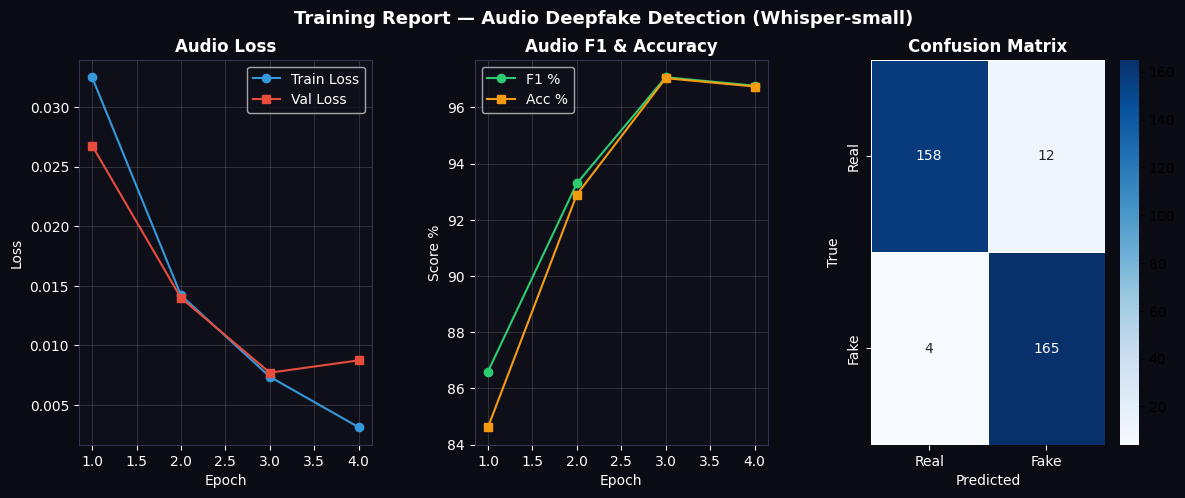

✅ Report → /kaggle/working/training_report.png


In [6]:
# ═══ Cell 5: Evaluation + Training Dashboard ════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

BG, BG2 = '#0b0b14', '#0f0f1a'

ckpt = torch.load(AUDIO_CKPT_PATH, map_location=DEVICE)
whisper_enc.load_state_dict(ckpt['whisper'])
audio_cls.load_state_dict(ckpt['classifier'])
whisper_enc.eval(); audio_cls.eval()
a_preds, a_trues = [], []
with torch.no_grad():
    for batch in audio_test_loader:
        feats  = batch[0].to(DEVICE)
        emb    = whisper_enc(feats)
        logit  = audio_cls(emb).squeeze(-1)
        pred   = (torch.sigmoid(logit) >= 0.5).long().cpu().numpy()
        a_preds.extend(pred); a_trues.extend(batch[1].numpy())
print('\n🧪 Audio Test Report:')
print(classification_report(a_trues, a_preds, target_names=['Real','Fake']))

fig = plt.figure(figsize=(14, 5), facecolor=BG)
gs  = gridspec.GridSpec(1, 3, figure=fig, hspace=0.4, wspace=0.35)
epochs_x = range(1, len(audio_history['train_loss']) + 1)

ax1 = fig.add_subplot(gs[0, 0]); ax1.set_facecolor(BG2)
ax1.plot(epochs_x, audio_history['train_loss'], 'o-', color='#3498db', label='Train Loss')
ax1.plot(epochs_x, audio_history['val_loss'],   's-', color='#e74c3c', label='Val Loss')
ax1.set_title('Audio Loss', color='white', fontweight='bold')
ax1.set_xlabel('Epoch', color='white'); ax1.set_ylabel('Loss', color='white')
ax1.tick_params(colors='white'); ax1.legend(facecolor=BG2, labelcolor='white')
ax1.grid(True, alpha=0.2)
for sp in ax1.spines.values(): sp.set_color('#333355')

ax2 = fig.add_subplot(gs[0, 1]); ax2.set_facecolor(BG2)
ax2.plot(epochs_x, [v*100 for v in audio_history['val_f1']],  'o-', color='#2ecc71', label='F1 %')
ax2.plot(epochs_x, [v*100 for v in audio_history['val_acc']], 's-', color='#f39c12', label='Acc %')
ax2.set_title('Audio F1 & Accuracy', color='white', fontweight='bold')
ax2.set_xlabel('Epoch', color='white'); ax2.set_ylabel('Score %', color='white')
ax2.tick_params(colors='white'); ax2.legend(facecolor=BG2, labelcolor='white')
ax2.grid(True, alpha=0.2)
for sp in ax2.spines.values(): sp.set_color('#333355')

ax3 = fig.add_subplot(gs[0, 2]); ax3.set_facecolor(BG2)
cm = confusion_matrix(a_trues, a_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'],
            ax=ax3, linewidths=0.5)
ax3.set_title('Confusion Matrix', color='white', fontweight='bold')
ax3.set_xlabel('Predicted', color='white'); ax3.set_ylabel('True', color='white')
ax3.tick_params(colors='white')

fig.suptitle('Training Report — Audio Deepfake Detection (Whisper-small)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('/kaggle/working/training_report.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Report → /kaggle/working/training_report.png')


In [7]:
# ═══ Cell 6: Gradio Inference Interface ════════════════════════════════
# Input: فيديو  →  يسحب منه الصوت بـ moviepy  →  يحلل الصوت فقط
import gradio as gr
import torch
import numpy as np
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tempfile, os
try:
    from moviepy.editor import VideoFileClip
except ImportError:
    from moviepy import VideoFileClip
from transformers import WhisperFeatureExtractor

# ── Load checkpoints ──────────────────────────────────────────────────────
print('Loading models...')
inf_whisper   = WhisperEncoder(MODEL_NAME).to(DEVICE)
inf_whisper.eval()

inf_audio_cls = AudioDeepfakeClassifier(input_dim=inf_whisper.hidden_size * 2, num_classes=1).to(DEVICE)
ckpt = torch.load(AUDIO_CKPT_PATH, map_location=DEVICE, weights_only=True)
inf_whisper.load_state_dict(ckpt['whisper'])
inf_audio_cls.load_state_dict(ckpt['classifier'])
inf_audio_cls.eval()

fe_inf = WhisperFeatureExtractor.from_pretrained(MODEL_NAME)
print('✅ Models ready')

C_FAKE, C_REAL = '#ef4444', '#10b981'


def analyze_audio(wav: np.ndarray) -> dict:
    wav = wav[:MAX_SAMPLES] if len(wav) >= MAX_SAMPLES \
          else np.pad(wav, (0, MAX_SAMPLES - len(wav)))
    feat = fe_inf(wav.astype(np.float32), sampling_rate=SAMPLE_RATE,
                  return_tensors='pt').input_features.to(DEVICE)
    feat.requires_grad_(True)
    inf_whisper.zero_grad(); inf_audio_cls.zero_grad()
    emb   = inf_whisper(feat)
    logit = inf_audio_cls(emb)
    prob_fake = float(torch.sigmoid(logit).item())
    logit.backward()
    grads = feat.grad.detach().cpu().numpy()[0]
    x_inp = feat.detach().cpu().numpy()[0]
    attr  = np.abs(grads * x_inp)
    attr  = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
    pred  = 1 if prob_fake >= 0.5 else 0
    return {
        'pred': pred, 'pred_str': 'FAKE' if pred else 'REAL',
        'prob_real': 1 - prob_fake, 'prob_fake': prob_fake,
        'conf': prob_fake if pred else 1 - prob_fake,
        'attr': attr, 'wav': wav,
    }


def build_figure(a_res):
    BG, BG2 = '#0b0b14', '#0f0f1a'
    Ca = C_FAKE if a_res['pred'] else C_REAL

    fig = plt.figure(figsize=(14, 5), facecolor=BG)
    gs  = gridspec.GridSpec(1, 3, figure=fig,
                            width_ratios=[2, 2, 1.2],
                            hspace=0.4, wspace=0.30)

    # Waveform
    wav = a_res['wav']
    t   = np.linspace(0, MAX_SECONDS, len(wav))
    ax  = fig.add_subplot(gs[0, 0]); ax.set_facecolor(BG2)
    ax.plot(t, wav, color=Ca, lw=0.5, alpha=0.85)
    ax.fill_between(t, wav, alpha=0.15, color=Ca)
    ax.set_title('🔊 Audio Waveform', color='white', fontweight='bold', fontsize=10)
    ax.set_xlabel('Time (s)', color='white', fontsize=9)
    ax.tick_params(colors='white', labelsize=8)
    for sp in ax.spines.values(): sp.set_color('#333355')

    # Attribution map
    attr_a    = a_res['attr']
    mel_freqs = librosa.mel_frequencies(n_mels=attr_a.shape[0], fmin=0, fmax=SAMPLE_RATE//2)
    ax2 = fig.add_subplot(gs[0, 1]); ax2.set_facecolor(BG2)
    im  = ax2.imshow(attr_a, aspect='auto', origin='lower', cmap='hot',
                     extent=[0, MAX_SECONDS, mel_freqs[0], mel_freqs[-1]])
    ax2.set_title('Audio Attribution\n(hot = model focused here)',
                  color='white', fontweight='bold', fontsize=10)
    ax2.set_xlabel('Time (s)', color='white', fontsize=9)
    ax2.set_ylabel('Freq (Hz)', color='white', fontsize=9)
    ax2.tick_params(colors='white', labelsize=8)
    fig.colorbar(im, ax=ax2, pad=0.02).ax.tick_params(colors='white', labelsize=7)

    # Verdict panel
    av = fig.add_subplot(gs[0, 2]); av.set_facecolor(BG2); av.axis('off')
    for y_pos, txt, sz, col in [
        (0.90, '🔊 VERDICT',                    11, '#aaaacc'),
        (0.64, a_res['pred_str'],                32, Ca),
        (0.44, f"Conf: {a_res['conf']*100:.1f}%", 10, 'white'),
        (0.30, f"P(Real)={a_res['prob_real']*100:.1f}%", 9, C_REAL),
        (0.16, f"P(Fake)={a_res['prob_fake']*100:.1f}%", 9, C_FAKE),
    ]:
        av.text(0.5, y_pos, txt, ha='center', color=col, fontsize=sz,
                fontweight='bold', transform=av.transAxes)

    fig.suptitle(
        f"Audio Deepfake Detection  |  Verdict: {a_res['pred_str']}",
        color=Ca, fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    return fig


def process_video(video_path):
    """يقبل فيديو → يسحب الصوت منه → يحلل الصوت فقط."""
    if video_path is None:
        return None, '⚠️ Please upload a video file.'
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            audio_tmp = tmp.name

        # سحب الصوت من الفيديو
        clip = VideoFileClip(video_path)
        if clip.audio is None:
            clip.close()
            return None, '❌ Video has no audio track.'
        clip.audio.write_audiofile(audio_tmp, fps=SAMPLE_RATE,
                                   verbose=False, logger=None)
        clip.close()

        # تحليل الصوت
        wav, _ = librosa.load(audio_tmp, sr=SAMPLE_RATE, mono=True)
        os.unlink(audio_tmp)

        a_res = analyze_audio(wav)
        fig   = build_figure(a_res)

        emoji   = '🔴' if a_res['pred'] else '🟢'
        verdict = (
            f"{emoji}  VERDICT: {a_res['pred_str']}\n\n"
            f"🔊 Audio Confidence : {a_res['conf']*100:.1f}%\n"
            f"   P(Real) = {a_res['prob_real']*100:.1f}%\n"
            f"   P(Fake) = {a_res['prob_fake']*100:.1f}%\n\n"
            f"ℹ️  Analysis based on audio track only."
        )
        return fig, verdict
    except Exception as e:
        return None, f'❌ Error: {str(e)}'


with gr.Blocks(
    title='Audio Deepfake Detector',
    theme=gr.themes.Base(primary_hue='red', neutral_hue='slate'),
    css='''
        .gradio-container { background: #0b0b14; }
        .gr-button { background: #ef4444 !important; border: none !important; }
        h1, h2, h3, label { color: white !important; }
        .gr-box { background: #0f0f1a !important; border-color: #333355 !important; }
    '''
) as demo:

    gr.Markdown('''
    # 🔊 Audio Deepfake Detector
    ### Upload a video → extracts audio automatically → analyzes audio only
    ---
    ''')
    with gr.Row():
        with gr.Column(scale=1):
            vid_in  = gr.Video(label='📹 Upload Video', height=280)
            btn     = gr.Button('🔍 Analyze Audio', variant='primary', size='lg')
            verdict = gr.Textbox(label='📋 Result', lines=8, interactive=False,
                                 placeholder='Result will appear here...')
        with gr.Column(scale=2):
            plot = gr.Plot(label='📊 Audio Analysis Dashboard')

    gr.Markdown('''
    ---
    **How it works:**
    - Extracts audio from the uploaded video using moviepy
    - Audio → Whisper-small encoder → AudioDeepfakeClassifier (sigmoid)
    - Attribution map shows *where* in the spectrogram the model focused
    - No video frames are analyzed
    ''')
    btn.click(fn=process_video, inputs=[vid_in], outputs=[plot, verdict])

print('\n🚀 Launching...')
demo.launch(share=True, debug=False)


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
A

Loading models...


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

✅ Models ready

🚀 Launching...
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://889b682938506403ae.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
